In [32]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

LABELS = [
    ('hse-ex1', 'defect_hse_excited_deltaQ', '4.0'),
    ("hse-ex1", "defect_zero_phonon_line", '4.0'), 
    ('hse-gs', 'defect_lvl_tdm', '4.0'),
    ('hse-gs', 'defect_total_energy', '4.0'), 
    ('hse-gs', 'defect_fermi_energy', '4.0'),
    ('pbe-gs', 'defect_cbm-vbm_energy', '4.0'),
    ('pbe-gs', 'defect_initial_pbe_deltaQ', '4.0'),
    ('pbe-gs', 'defect_initial_pbe_deltaR', '4.0'),
    ('pbe-gs', 'defect_electron_affinity', '4.0'),
    ('pbe-gs', 'defect_ionization_energy', '4.0')
]

NAMES = [
    "Excited State Delta Q",
    "Zero Phonon Line",
    "Level TDM",
    "Defect Energy",
    "Fermi Energy",
    "CBM-VBM Energy",
    "Initial PBE Delta Q",
    "Initial PBE Delta R",
    "Electron Affinity",
    "Ionization Energy"
]

NAMES = NAMES[::-1]

In [52]:
import torch
import GCN
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.utils import dense_to_sparse
from torch_geometric.data import Data

import importlib
import os
importlib.reload(GCN)

def plot_or_save(label1, label2, version, save = False, alpha=0.5):

    if not os.path.exists(f'filtered_data/{label1}_{label2}_X_val.npy'):
        raise FileNotFoundError(f"Label not founnd")


    if save:
        folder_path = f'pictures/{label1}_{label2}'
        os.makedirs(folder_path, exist_ok=True)


    types = ['val', 'train']
    error = [0, 0]
    data = [None]*4
    
    # Enhanced figure for poster
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    fig.suptitle(f'{label1}_{label2} Predictions', fontsize=28, fontweight='bold', color='#2C3E50')

    for index, t_val in enumerate(types):

        # Load validation data
        data_x = np.load(f'filtered_data/{label1}_{label2}_X_{t_val}.npy')
        data_adj = np.load(f'filtered_data/{label1}_{label2}_adj_{t_val}.npy')
        data_y = np.load(f'filtered_data/{label1}_{label2}_y_{t_val}.npy')

        norm = np.load(f'filtered_data/{label1}_{label2}_norm_params.npy')

        # Convert to tensors
        device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
        X_val_tensor = torch.tensor(data_x, dtype=torch.float).to(device)
        adj_val_tensor = torch.tensor(data_adj, dtype=torch.float).to(device)
        y_val_tensor = torch.tensor(data_y, dtype=torch.float).to(device)

        model = GCN.GraphConv(20, 0.001).to(device)
        model.load_state_dict(torch.load(f'./models/model_{label1}_{label2}{version}.pt', map_location=device))
        model.eval()


        # Prepare validation dataset for prediction
        val_graphs = []
        for i in range(len(X_val_tensor)):
            edge_index, _ = dense_to_sparse(adj_val_tensor[i, :GCN.GRAPH_SIZE, :GCN.GRAPH_SIZE])
            data = Data(x=X_val_tensor[i, :GCN.GRAPH_SIZE], edge_index=edge_index)
            val_graphs.append(data)

        # Predict on validation set
        preds = []
        with torch.no_grad():
            for data in val_graphs:
                x = data.x
                edge_index = data.edge_index
                batch = torch.zeros(x.size(0), dtype=torch.long, device=device)
                pred = model(x, data.edge_index, data.edge_weight, batch)
                preds.append(pred.cpu().numpy().flatten()[0])

        preds = np.array(preds)
        y_true = y_val_tensor.cpu().numpy().flatten()

        converted_preds = preds * (norm[1] - norm[0]) + norm[0]
        converted_y_true = y_true * (norm[1] - norm[0]) + norm[0]

        ax = axes[index]
        
        # Enhanced scatter plot
        ax.scatter(converted_y_true, converted_preds, color='#4A90E2', alpha=alpha, 
                  s=80, edgecolors='white', linewidth=1.5, zorder=3)
        
        ax.set_xlabel('Actual (eV)', fontsize=20, fontweight='bold', color='#2C3E50')
        ax.set_ylabel('Predicted (eV)', fontsize=20, fontweight='bold', color='#2C3E50')
        
        if index == 0:
            ax.set_title('Testing Set', fontsize=24, fontweight='bold', color='#2C3E50', pad=15)
        else:
            ax.set_title('Training Set', fontsize=24, fontweight='bold', color='#2C3E50', pad=15)
        
        # Perfect prediction line
        ax.plot([converted_y_true.min(), converted_y_true.max()], 
               [converted_y_true.min(), converted_y_true.max()], 
               '--', color='#E74C3C', linewidth=3, label='Perfect Prediction', zorder=4)
        
        # Enhanced grid and styling
        ax.grid(True, linestyle='--', linewidth=1, alpha=0.3, zorder=1)
        ax.set_axisbelow(True)
        ax.tick_params(axis='both', labelsize=16, colors='#2C3E50', width=2, length=6)
        
        # Enhanced legend
        legend = ax.legend(fontsize=16, frameon=True, shadow=True, fancybox=True, framealpha=0.95)
        legend.get_frame().set_facecolor('white')
        legend.get_frame().set_edgecolor('#2C3E50')
        legend.get_frame().set_linewidth(2)
        
        # Spine styling
        for spine in ax.spines.values():
            spine.set_edgecolor('#2C3E50')
            spine.set_linewidth(2)
        
        # Background
        ax.set_facecolor('#FAFAFA')
        
        residuals = preds - y_true
        error[index] = np.mean(residuals**2)

    fig.patch.set_facecolor('white')
    plt.tight_layout()
    if save:
        plt.savefig(f'pictures/{label1}_{label2}/corr_{version}.png', dpi=300, bbox_inches='tight', facecolor='white')

    plt.show()

    # Enhanced residuals plot
    fig_res, axes_res = plt.subplots(1, 2, figsize=(18, 7))
    fig_res.suptitle(f'Analysis for {label1}_{label2}', fontsize=26, fontweight='bold', color='#2C3E50')

    # Plot residuals with enhanced styling
    axes_res[0].hist(residuals, bins=50, color='#4A90E2', alpha=0.7, edgecolor='white', linewidth=1.5)
    axes_res[0].set_xlabel('Residual (Predicted - Actual)', fontsize=18, fontweight='bold', color='#2C3E50')
    axes_res[0].set_ylabel('Frequency', fontsize=18, fontweight='bold', color='#2C3E50')
    axes_res[0].set_title('Prediction Residuals', fontsize=22, fontweight='bold', color='#2C3E50', pad=15)
    axes_res[0].grid(True, linestyle='--', linewidth=1, alpha=0.3, zorder=1)
    axes_res[0].set_axisbelow(True)
    axes_res[0].tick_params(axis='both', labelsize=14, colors='#2C3E50', width=2, length=6)
    for spine in axes_res[0].spines.values():
        spine.set_edgecolor('#2C3E50')
        spine.set_linewidth(2)
    axes_res[0].set_facecolor('#FAFAFA')

    # Plot actual data distribution with enhanced styling
    axes_res[1].hist(y_true, bins=50, color='#50C878', alpha=0.7, edgecolor='white', linewidth=1.5)
    axes_res[1].set_xlabel('Normalized Values', fontsize=18, fontweight='bold', color='#2C3E50')
    axes_res[1].set_ylabel('Frequency', fontsize=18, fontweight='bold', color='#2C3E50')
    axes_res[1].set_title('Data Distribution', fontsize=22, fontweight='bold', color='#2C3E50', pad=15)
    axes_res[1].grid(True, linestyle='--', linewidth=1, alpha=0.3, zorder=1)
    axes_res[1].set_axisbelow(True)
    axes_res[1].tick_params(axis='both', labelsize=14, colors='#2C3E50', width=2, length=6)
    for spine in axes_res[1].spines.values():
        spine.set_edgecolor('#2C3E50')
        spine.set_linewidth(2)
    axes_res[1].set_facecolor('#FAFAFA')

    fig_res.patch.set_facecolor('white')
    plt.tight_layout()

    if save:
        plt.savefig(f'pictures/{label1}_{label2}/residuals_{version}.png', dpi=300, facecolor='white')

    plt.show()

    amount = len(y_true)

    random_guess_error = 0
    for i in range(amount):
        random_guess = np.random.uniform(0, 1)
        random_guess_error += (random_guess - y_true[i])**2

    random_guess_error /= amount

    mean_guess = np.mean(y_true)
    mean_guess_error = np.mean((mean_guess - y_true) ** 2)

    prediction_power_mean = random_guess_error / mean_guess_error
    prediction_power_val = random_guess_error / error[0]
    prediction_power_train = random_guess_error / error[1]
    
    # Enhanced bar plot of prediction power
    fig_power, ax_power = plt.subplots(figsize=(12, 8))
    
    x_pos = np.arange(4)
    powers = [1, prediction_power_mean, prediction_power_val, prediction_power_train]
    labels_power = ['Random\nGuess', 'Mean\nGuess', 'Model\n(Val)', 'Model\n(Train)']
    colors = ['#B0B0B0', '#4A90E2', '#50C878', "#CC532E"]
    
    bars = ax_power.bar(x_pos, powers, color=colors, alpha=0.8, 
                        edgecolor='white', linewidth=2, width=0.6)
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, powers)):
        height = bar.get_height()
        ax_power.text(bar.get_x() + bar.get_width()/2., height,
                     f'{val:.2f}',
                     ha='center', va='bottom', fontsize=16, fontweight='bold', color='#2C3E50')
    
    ax_power.set_xticks(x_pos)
    ax_power.set_xticklabels(labels_power, fontsize=18, fontweight='bold', color='#2C3E50')
    ax_power.set_ylabel('Prediction Power', fontsize=22, fontweight='bold', color='#2C3E50')
    ax_power.set_title(f'Prediction Power: {label1}_{label2}', fontsize=26, 
                       fontweight='bold', pad=20, color='#2C3E50')
    
    # Enhanced styling
    ax_power.grid(True, axis='y', linestyle='--', linewidth=1.2, alpha=0.3, zorder=1)
    ax_power.set_axisbelow(True)
    ax_power.tick_params(axis='y', labelsize=16, colors='#2C3E50', width=2, length=6)
    
    for spine in ax_power.spines.values():
        spine.set_edgecolor('#2C3E50')
        spine.set_linewidth(2)
    
    ax_power.set_facecolor('#FAFAFA')
    fig_power.patch.set_facecolor('white')
    
    plt.tight_layout()
    if save:
        plt.savefig(f'pictures/{label1}_{label2}/power_{version}.png', dpi=300, facecolor='white')
    plt.show()

    print(f"MSE - Mean: {mean_guess_error:.4f}, Val: {error[0]:.4f}, Train: {error[1]:.4f}")
    



/tmp/ipykernel_3546/817786788.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'./models/model_{label1}_{label2}{version}.pt', map_loca

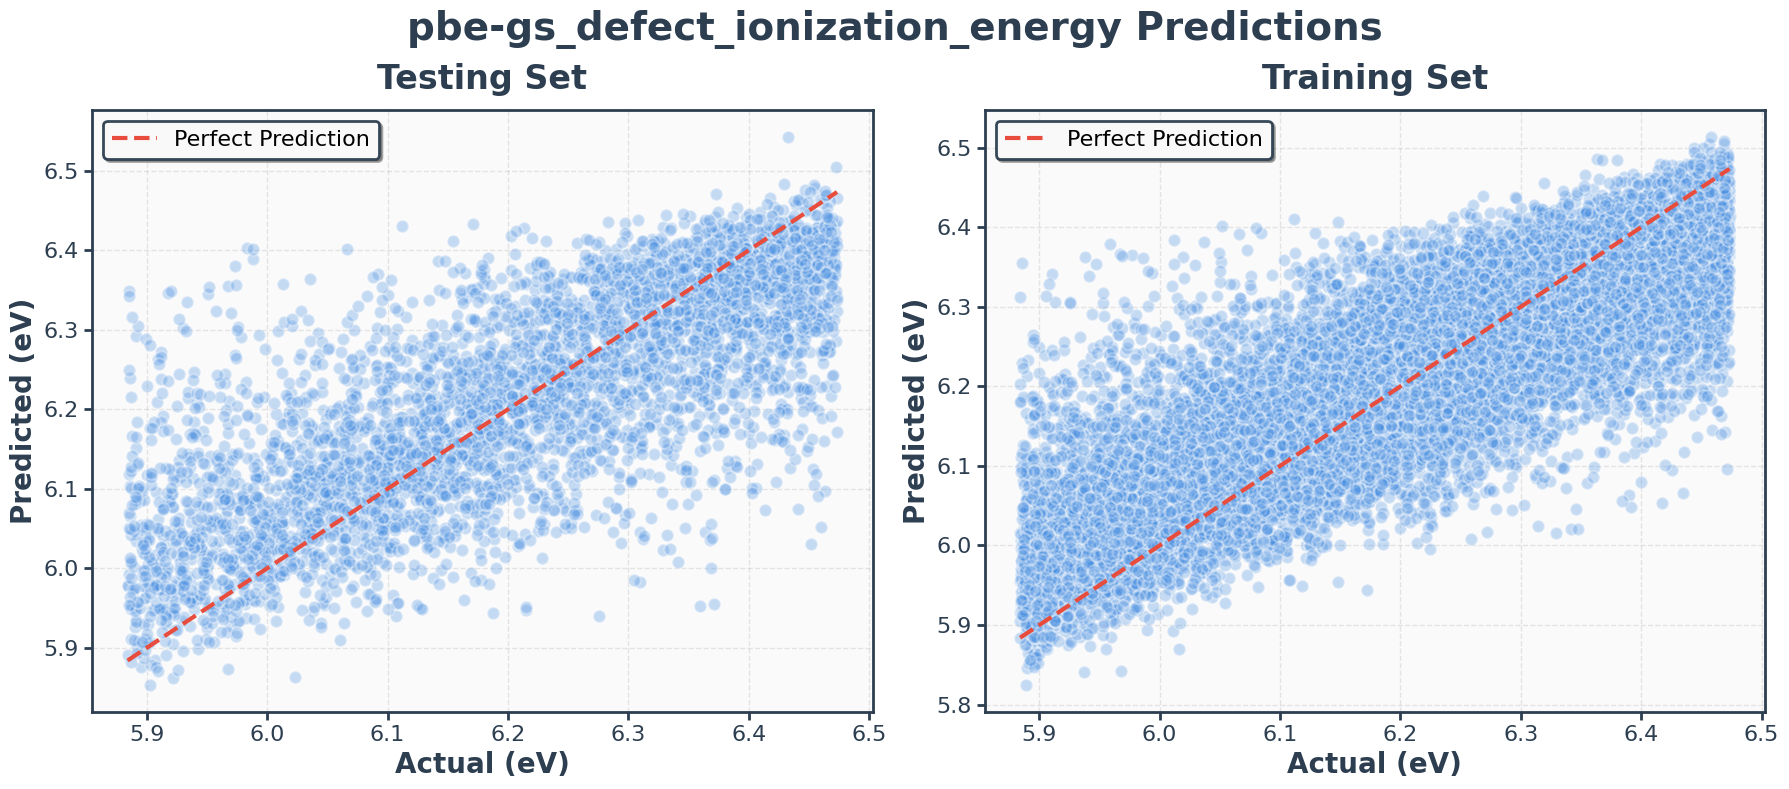

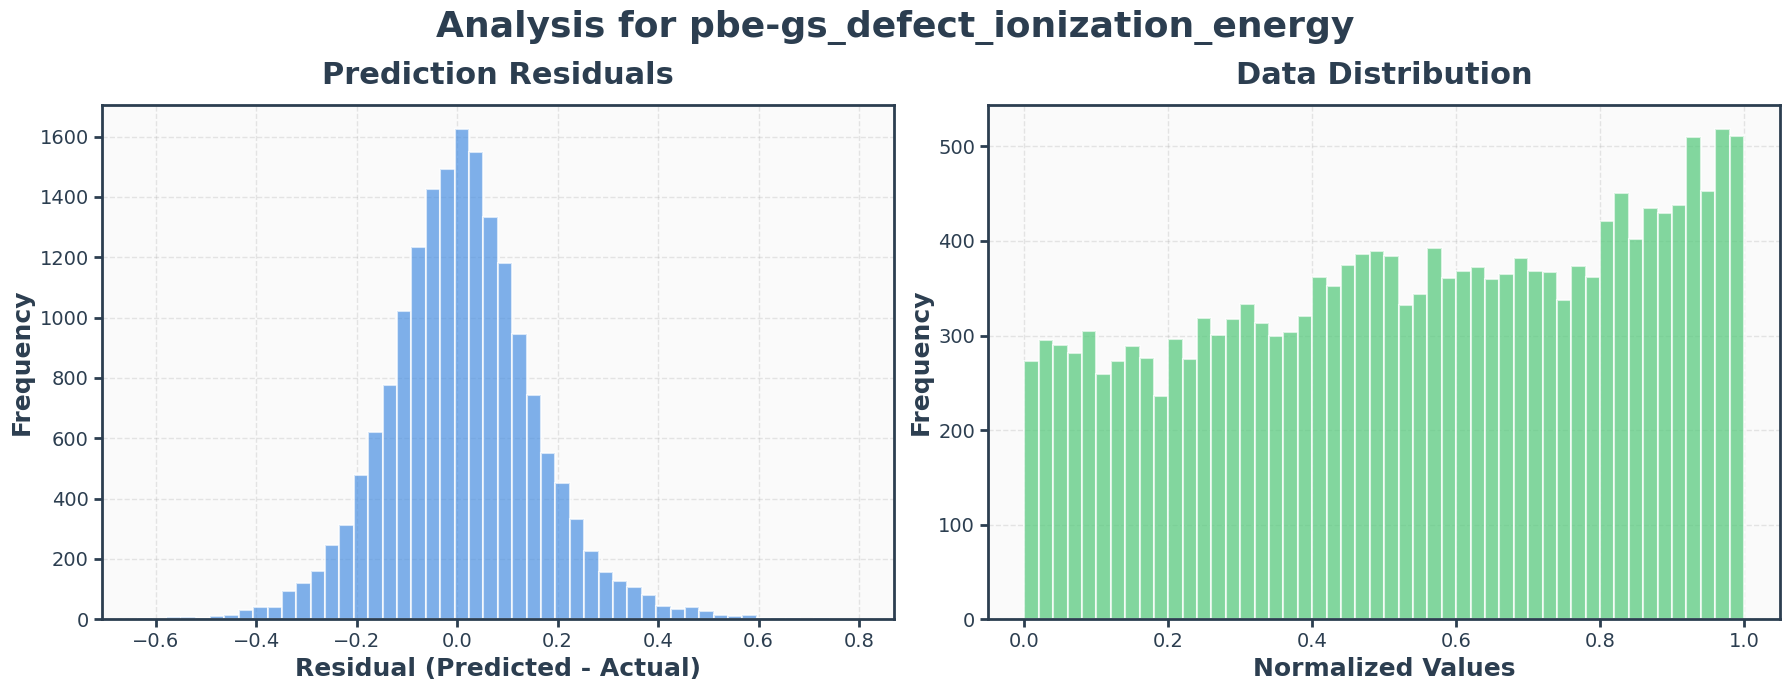

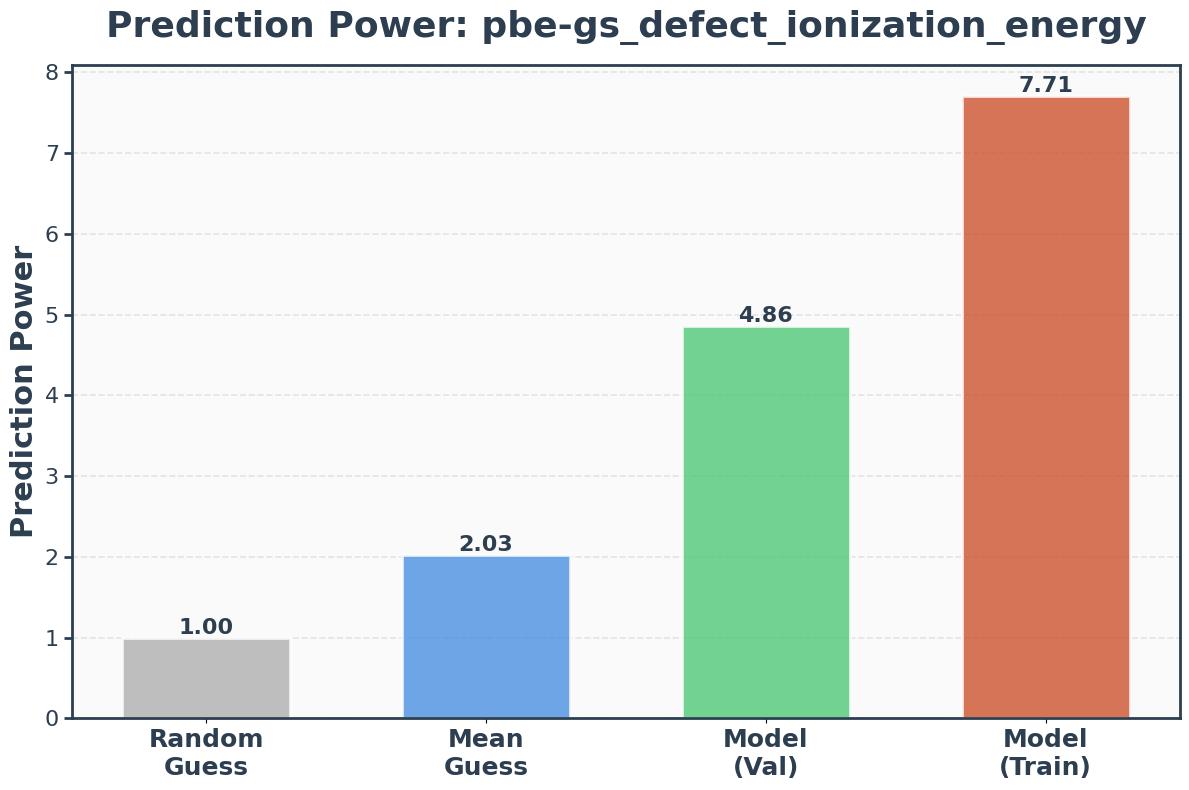

MSE - Mean: 0.0834, Val: 0.0348, Train: 0.0219


In [55]:
import importlib
import os
importlib.reload(GCN)

LABELS = [
    # ('hse-ex1', 'defect_hse_excited_deltaQ', '4.0'),
    # ("hse-ex1", "defect_zero_phonon_line", '4.0'), 
    # ('hse-gs', 'defect_lvl_tdm', '4.0'),
    # ('hse-gs', 'defect_total_energy', '4.0'), 
    # ('hse-gs', 'defect_fermi_energy', '4.0'),
    # ('pbe-gs', 'defect_cbm-vbm_energy', '4.0'),
    # ('pbe-gs', 'defect_initial_pbe_deltaQ', '4.0'),
    # ('pbe-gs', 'defect_initial_pbe_deltaR', '4.0'),
    # ('pbe-gs', 'defect_electron_affinity', '4.0'),
    ('pbe-gs', 'defect_ionization_energy', '4.0')
]

for label1, label2, version in LABELS:
    if label1 == "pbe-gs":
        plot_or_save(label1, label2, version, save=True, alpha=0.3)
    else:
        plot_or_save(label1, label2, version, save=True, alpha=0.5)


/tmp/ipykernel_3546/1747815282.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'./models/model_{label1}_{label2}{version}.pt', map_loc

[(np.float32(2.0023708), np.float32(4.687456)), (np.float32(2.0761397), np.float32(4.7384696)), (np.float32(3.3910742), np.float32(22.400911)), (np.float32(3.7213364), np.float32(20.313213)), (np.float32(2.6491911), np.float32(2.8027003)), (np.float32(1.9773788), np.float32(3.4650545)), (np.float32(2.345537), np.float32(10.361696)), (np.float32(2.7471113), np.float32(2.7533224)), (np.float32(2.0362697), np.float32(2.8244286)), (np.float32(4.755061), np.float32(5.042617))]


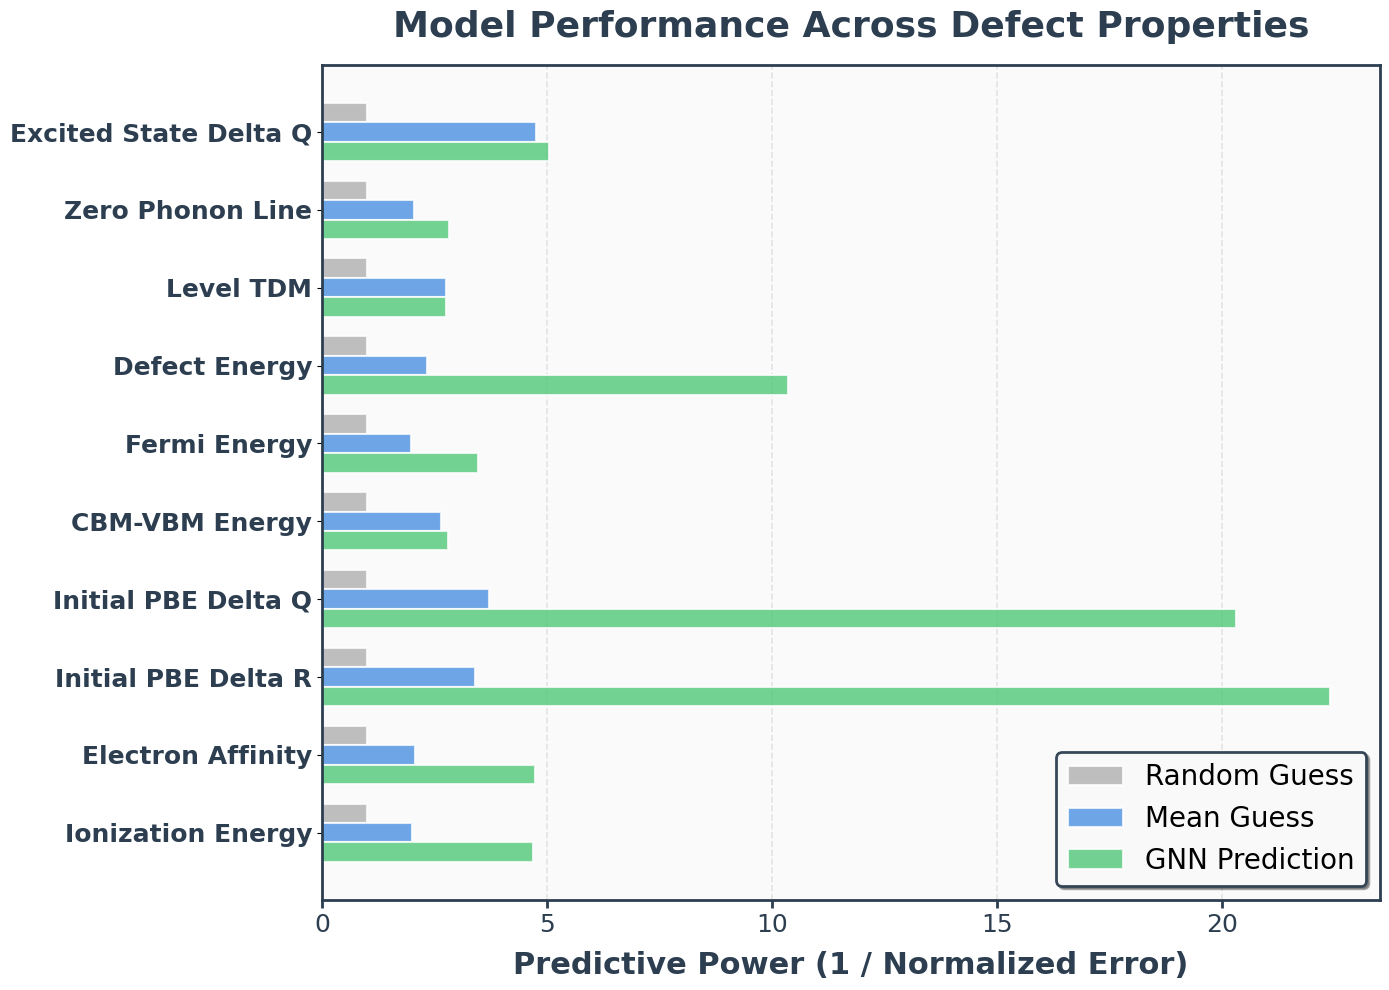

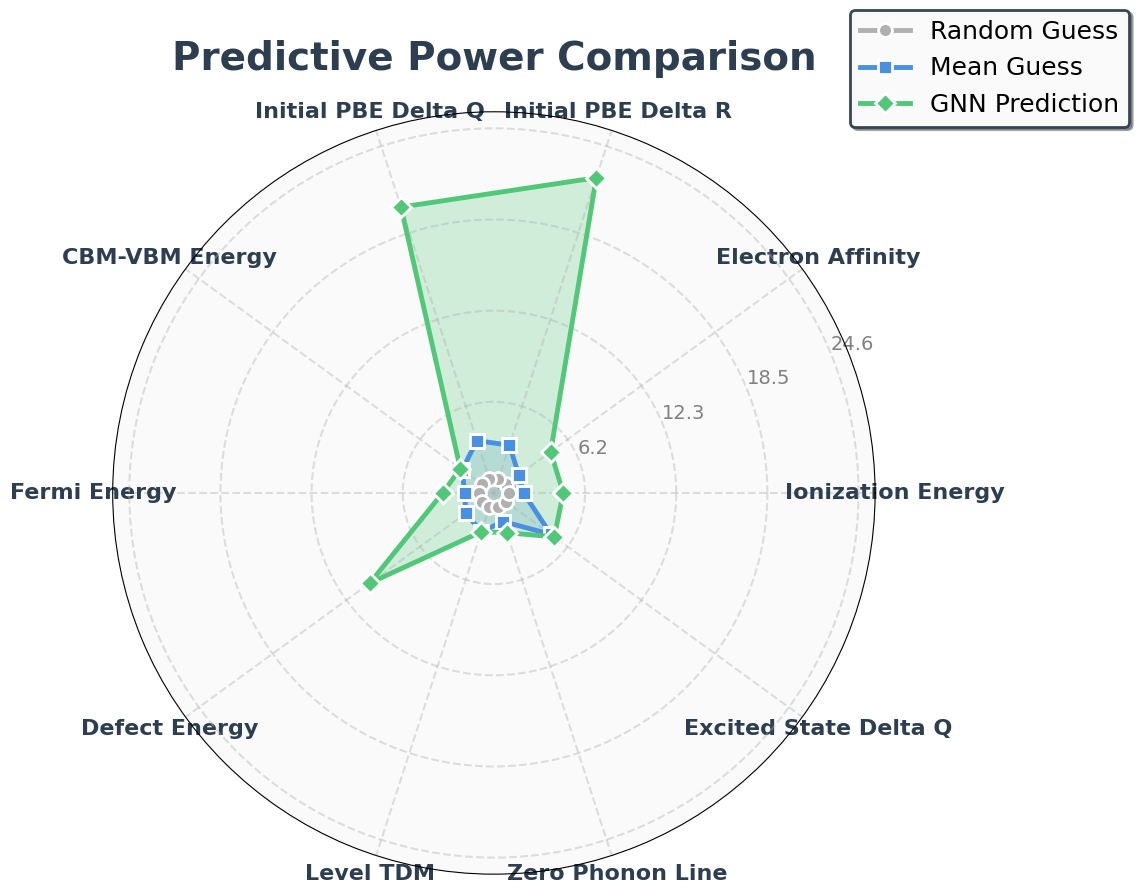

In [44]:
import torch
import GCN
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.utils import dense_to_sparse
from torch_geometric.data import Data

import importlib
import os
importlib.reload(GCN)

def computePowers(label1, label2, version, save = False):


    # Load validation data
    data_x = np.load(f'filtered_data/{label1}_{label2}_X_val.npy')
    data_adj = np.load(f'filtered_data/{label1}_{label2}_adj_val.npy')
    data_y = np.load(f'filtered_data/{label1}_{label2}_y_val.npy')

    # Convert to tensors
    #device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    device = torch.device('cpu')
    X_val_tensor = torch.tensor(data_x, dtype=torch.float).to(device)
    adj_val_tensor = torch.tensor(data_adj, dtype=torch.float).to(device)
    y_val_tensor = torch.tensor(data_y, dtype=torch.float).to(device)

    model = GCN.GraphConv(20, 0.001).to(device)
    model.load_state_dict(torch.load(f'./models/model_{label1}_{label2}{version}.pt', map_location=device))
    model.eval()

    # Prepare validation dataset for prediction
    val_graphs = []
    for i in range(len(X_val_tensor)):
        edge_index, _ = dense_to_sparse(adj_val_tensor[i, :GCN.GRAPH_SIZE, :GCN.GRAPH_SIZE])
        data = Data(x=X_val_tensor[i, :GCN.GRAPH_SIZE], edge_index=edge_index)
        val_graphs.append(data)

    # Predict on validation set
    preds = []
    with torch.no_grad():
        for data in val_graphs:
            x = data.x
            edge_index = data.edge_index
            batch = torch.zeros(x.size(0), dtype=torch.long, device=device)
            pred = model(x, data.edge_index, data.edge_weight, batch)
            preds.append(pred.cpu().numpy().flatten()[0])
            #preds.append(0.5)

    preds = np.array(preds)
    y_true = y_val_tensor.cpu().numpy().flatten()
    residuals = preds - y_true

    amount = len(y_true)

    random_guess_error = 0
    for i in range(amount):
        random_guess = np.random.uniform(0, 1)
        random_guess_error += (random_guess - y_true[i])**2

    random_guess_error /= amount

    mean_guess = np.mean(y_true)
    mean_guess_error = np.mean((mean_guess - y_true) ** 2)

    prediction_power_mean = random_guess_error / mean_guess_error
    prediction_power_val = random_guess_error / np.mean(residuals**2)  # RMSE in original scale
    #prediction_power_train = random_guess_error / error[1]  # Using training RMSE
    

    return (prediction_power_mean, prediction_power_val)


powers = []

for label1, label2, version in LABELS:
    powers.append(computePowers(label1, label2, version, save=True))

powers = powers[::-1]

print(powers)
# Labels for the bars


# Extract mean and val powers
mean_powers = [p[0] for p in powers]
val_powers = [p[1] for p in powers]

# Create horizontal bar plot - Enhanced for poster
fig, ax = plt.subplots(figsize=(14, 10))
y_pos = range(len(NAMES))

# Enhanced color scheme
random_color = '#B0B0B0'
mean_color = '#4A90E2'
gnn_color = '#50C878'

# Create bars with enhanced styling
bar_height = 0.25
ax.barh([y + bar_height for y in y_pos], [1] * len(NAMES), height=bar_height, 
        label='Random Guess', color=random_color, alpha=0.8, 
        edgecolor='white', linewidth=1.5, zorder=2)
ax.barh([y for y in y_pos], mean_powers, height=bar_height, 
        label='Mean Guess', color=mean_color, alpha=0.8,
        edgecolor='white', linewidth=1.5, zorder=2)
ax.barh([y - bar_height for y in y_pos], val_powers, height=bar_height, 
        label='GNN Prediction', color=gnn_color, alpha=0.8,
        edgecolor='white', linewidth=1.5, zorder=2)

# Customize y-axis
ax.set_yticks(y_pos)
ax.set_yticklabels(NAMES, fontsize=18, fontweight='bold', color='#2C3E50')

# Customize x-axis
ax.set_xlabel('Predictive Power (1 / Normalized Error)', fontsize=22, 
              fontweight='bold', color='#2C3E50', labelpad=10)
ax.tick_params(axis='x', labelsize=18, colors='#2C3E50', width=2, length=6)

# Add title
ax.set_title('Model Performance Across Defect Properties', fontsize=26, 
             fontweight='bold', pad=20, color='#2C3E50')

# Enhanced grid
ax.grid(True, axis='x', linestyle='--', linewidth=1.2, alpha=0.3, zorder=1)
ax.set_axisbelow(True)

# Enhanced legend
legend = ax.legend(fontsize=20, frameon=True, shadow=True, 
                   fancybox=True, framealpha=0.95, loc='lower right',
                   edgecolor='#2C3E50')
legend.get_frame().set_facecolor('white')
legend.get_frame().set_linewidth(2)

# Spine styling
for spine in ax.spines.values():
    spine.set_edgecolor('#2C3E50')
    spine.set_linewidth(2)

# Set background colors
ax.set_facecolor('#FAFAFA')
fig.patch.set_facecolor('white')

# # Add value labels on bars for GNN predictions
# for i, (val, mean) in enumerate(zip(val_powers, mean_powers)):
#     if val > 1.5:  # Only label significant improvements
#         ax.text(val + 0.2, i - bar_height, f'{val:.1f}', 
#                 va='center', fontsize=14, fontweight='bold', color=gnn_color)

plt.tight_layout()
plt.savefig('pictures/predictive_power.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()



# Spider plot - Enhanced for poster
categories = NAMES
fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(projection='polar'))

# Number of variables
num_vars = len(categories)

# Compute angle for each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# Complete the loop
angles += angles[:1]
random_guess = [1] * len(NAMES)
random_guess_closed = random_guess + random_guess[:1]
mean_powers_closed = mean_powers + mean_powers[:1]
val_powers_closed = val_powers + val_powers[:1]

# Enhanced color scheme
random_color = '#B0B0B0'
mean_color = '#4A90E2'
gnn_color = '#50C878'

# Fill areas with gradient effect
ax.fill(angles, random_guess_closed, color=random_color, alpha=0.15)
ax.fill(angles, mean_powers_closed, color=mean_color, alpha=0.2)
ax.fill(angles, val_powers_closed, color=gnn_color, alpha=0.25)

# Plot lines with enhanced styling
ax.plot(angles, random_guess_closed, 'o-', linewidth=3.5, label='Random Guess', 
        color=random_color, markersize=10, markeredgewidth=2, markeredgecolor='white')
ax.plot(angles, mean_powers_closed, 's-', linewidth=3.5, label='Mean Guess', 
        color=mean_color, markersize=10, markeredgewidth=2, markeredgecolor='white')
ax.plot(angles, val_powers_closed, 'D-', linewidth=3.5, label='GNN Prediction', 
        color=gnn_color, markersize=10, markeredgewidth=2, markeredgecolor='white')

# Customize radial gridlines
ax.set_ylim(0, max(1, max(mean_powers), max(val_powers)) * 1.15)
ax.set_yticks(np.linspace(0, max(1, max(mean_powers), max(val_powers)) * 1.1, 5))
ax.set_yticklabels([f'{x:.1f}' for x in np.linspace(0, max(1, max(mean_powers), max(val_powers)) * 1.1, 5)], 
                    fontsize=14, color='gray')
ax.grid(True, linestyle='--', linewidth=1.5, alpha=0.4)

# Customize angular labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=16, fontweight='bold', color='#2C3E50')

# Add title with better styling
ax.set_title('Predictive Power Comparison', size=28, fontweight='bold', 
             pad=30, color='#2C3E50')

# Enhanced legend
legend = ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), 
                   fontsize=18, frameon=True, shadow=True, 
                   fancybox=True, framealpha=0.95)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('#2C3E50')
legend.get_frame().set_linewidth(2)

# Set background color
ax.set_facecolor('#FAFAFA')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.savefig('pictures/spider_predictive_power.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

/tmp/ipykernel_3546/2596432257.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_3546/2596432257.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_3546/2596432257.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_3546/2596432257.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_3546/2596432257.py:23: UserWarning: No artists with labels found to put in legend.  Note that art

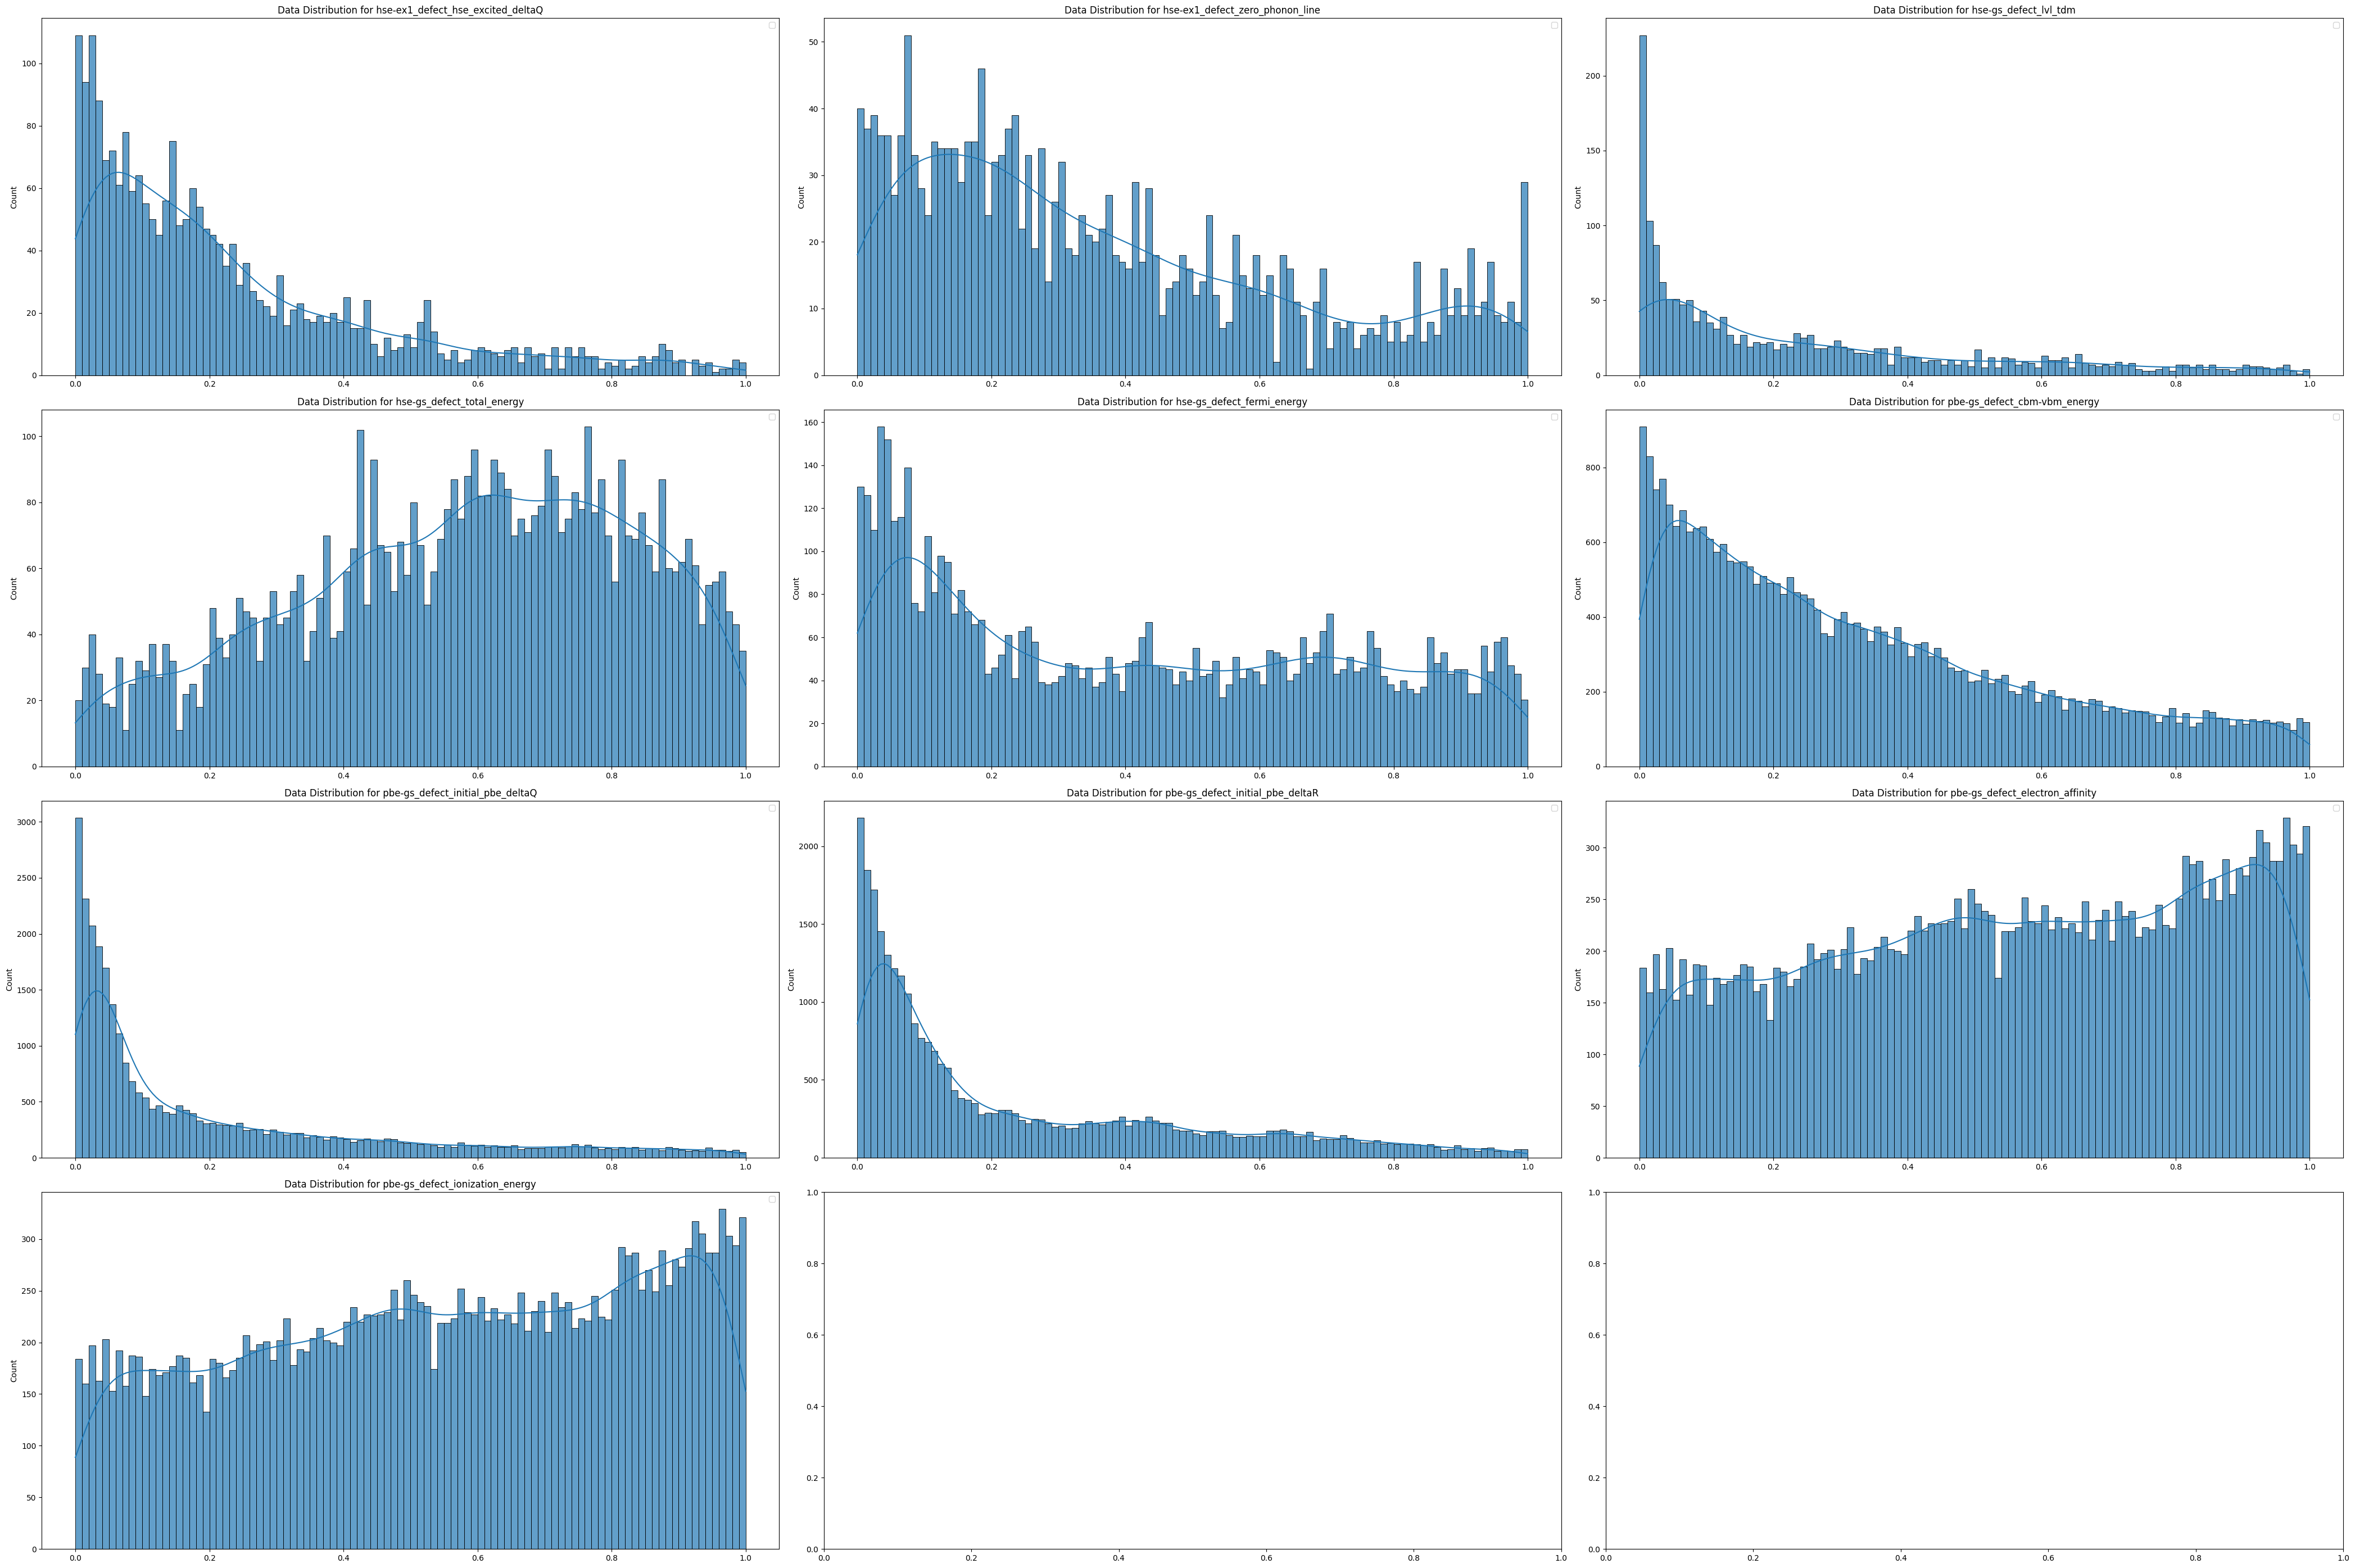

In [26]:
import math



def dataDistributions(label_list, save=False):
    if not isinstance(label_list, list):
        label_list = [label_list]  # If single tuple, wrap in list
    
    cols = 3
    rows = math.ceil(len(label_list) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(14 * cols, 7 * rows))
    axes = axes.flatten()[:len(label_list)]  # Flatten and slice to match number of plots
    
    for i, (label1, label2, _) in enumerate(label_list):
        data_val = np.load(f'filtered_data/{label1}_{label2}_y_val.npy')
        data_train = np.load(f'filtered_data/{label1}_{label2}_y_train.npy')

        data = np.concatenate((data_val, data_train), axis=0)
        
        ax = axes[i]
        sns.histplot(data, bins=100, kde=True, ax=ax, alpha=0.7)
        ax.set_title(f'Data Distribution for {label1}_{label2}')
        ax.legend()
    
    plt.tight_layout()
    plt.show()




dataDistributions(LABELS, save=False)


# powers = []

# for label1, label2, version in [('hse-gs', 'defect_total_energy', '2.1'), 
#                                 ("hse-ex1", "defect_zero_phonon_line", "2.0"), 
#                                 ('hse-gs', 'defect_lvl_tdm', '2.0'),
#                                 ('hse-ex1', 'defect_hse_excited_deltaQ', '2.0'),
#                                 ('hse-gs', 'defect_fermi_energy', '2.0')]:
#     powers.append(computePowers(label1, label2, version, save=True))

# print(powers)
# # Labels for the bars
# labels = ['Defect Energy', 'Zero Phonon Line', 'Level TDM', 'HSE Excited Delta Q', 'Fermi Energy']

# # Extract mean and val powers
# mean_powers = [p[0] for p in powers]
# val_powers = [p[1] for p in powers]

# # Create horizontal bar plot
# fig, ax = plt.subplots(figsize=(10, 6))
# y_pos = range(len(labels))

# ax.barh([y + 0.3 for y in y_pos], [1] * len(labels), height=0.3, label='Random Guess', color='lightgray')
# ax.barh([y for y in y_pos], mean_powers, height=0.3, label='Mean Guess', color='skyblue')
# ax.barh([y - 0.3 for y in y_pos], val_powers, height=0.3, label='GNN Prediction', color='lightgreen')
# ax.set_yticks(y_pos)
# ax.set_yticklabels(labels, fontsize=20)
# ax.set_xlabel('1 / Normalized Error', fontsize=22)
# ax.set_title('Predictive Power', fontsize=24)
# ax.tick_params(axis='x', labelsize=20)
# ax.legend(fontsize=20)
# plt.tight_layout()
# plt.savefig('pictures/predictive_power.png', dpi=300)
# plt.show()

/tmp/ipykernel_3546/2546746043.py:29: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'./models/model_{label1}_{label2}{version}.pt', map_loc

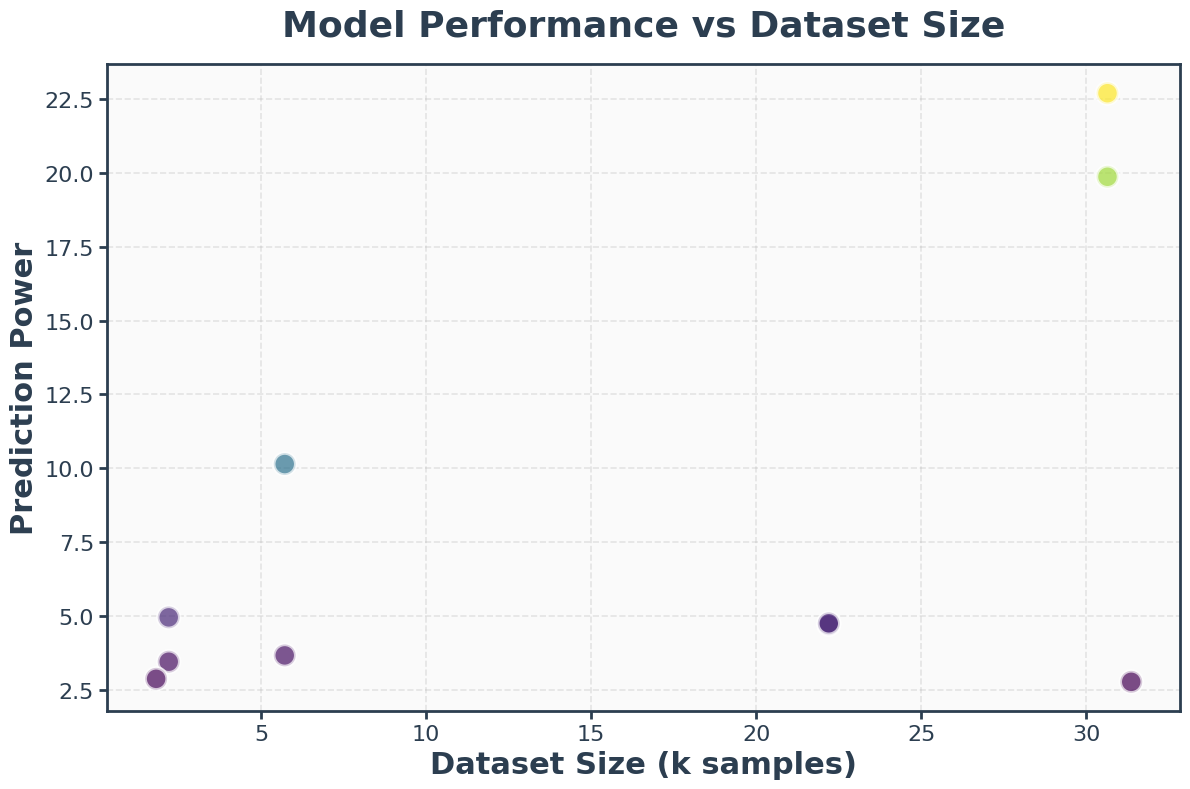

In [41]:
# hse-ex1_defect_zero_phonon_line   2k          val 0.056
# hse-ex1_defect_hse_excited_deltaQ 2.2k        val 0.045

# hse-gs_defect_fermi_energy        5.715k      val 0.0460
# hse-gs_defect_total_energy        5.715k      val 0.0141
# hse-gs_defect_vbm_energy          5.715k      val 0.0549
# hse-gs defect_lvl_tdm             1.819k      val 0.0714

#2/3 hours
# pbe-gs_defect_ionization_energy   22.197k     val 0.0348
# pbe-gs_defect_electron_affinity   22.197k     val 0.0357 run another 20
# pbe-gs_defect_initial_pbe_deltaR  30.641k     val 0.0095   
# pbe-gs_defect_initial_pbe_deltaQ  30.641k     val 0.0114           
# pbe-gs_defect_cbm-vbm_energy      31.361k     val 0.0648  

data_sizes = {
            "defect_zero_phonon_line": 2.2,
            "defect_hse_excited_deltaQ": 2.2,
            "defect_fermi_energy": 5.715,
            "defect_total_energy": 5.715,
            "defect_vbm_energy": 5.715,
            "defect_lvl_tdm": 1.819,
            "defect_cbm-vbm_energy": 31.361,
            "defect_initial_pbe_deltaQ": 30.641,
            "defect_initial_pbe_deltaR": 30.641,
            "defect_electron_affinity": 22.197,
            "defect_ionization_energy": 22.197
              }


data_x = []
data_y = []
labels_list = []

for label1, label2, version in LABELS:
    data_x.append(data_sizes[label2])
    out = computePowers(label1, label2, version)
    data_y.append(out[1])
    labels_list.append(label2)

# Enhanced scatter plot for poster
fig, ax = plt.subplots(figsize=(12, 8))

# Create scatter plot with enhanced styling
scatter = ax.scatter(data_x, data_y, s=250, c=data_y, #cmap='viridis', 
                     alpha=0.7, edgecolors='white', linewidth=2.5, 
                     zorder=3)

# # Add colorbar with label
# cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
# cbar.set_label('Prediction Power', fontsize=18, fontweight='bold')
# cbar.ax.tick_params(labelsize=14)

# # Fit a trend line
# z = np.polyfit(data_x, data_y, 1)
# p = np.poly1d(z)
# x_trend = np.linspace(min(data_x), max(data_x), 100)
# ax.plot(x_trend, p(x_trend), '--', color='#E74C3C', linewidth=3, 
#         alpha=0.8, label=f'Trend: y={z[0]:.3f}x+{z[1]:.2f}', zorder=2)

# Enhanced styling
ax.set_xlabel('Dataset Size (k samples)', fontsize=22, fontweight='bold', color='#2C3E50')
ax.set_ylabel('Prediction Power', fontsize=22, fontweight='bold', color='#2C3E50')
ax.set_title('Model Performance vs Dataset Size', fontsize=26, 
             fontweight='bold', pad=20, color='#2C3E50')

# Grid styling
ax.grid(True, linestyle='--', linewidth=1.2, alpha=0.3, zorder=1)
ax.set_axisbelow(True)

# Tick styling
ax.tick_params(axis='both', labelsize=16, colors='#2C3E50', width=2, length=6)
for spine in ax.spines.values():
    spine.set_edgecolor('#2C3E50')
    spine.set_linewidth(2)

# Legend with enhanced styling
# legend = ax.legend(fontsize=16, frameon=True, shadow=True, 
#                    fancybox=True, framealpha=0.95, loc='lower right')
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('#2C3E50')
legend.get_frame().set_linewidth(2)

# Set background color
ax.set_facecolor('#FAFAFA')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.savefig('pictures/poster/dataFit.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()




In [4]:
import torch
from torchviz import make_dot
import GCN
from torch_geometric.data import Data
import importlib
from IPython.display import SVG

importlib.reload(GCN)

# Create a simple model instance
device = torch.device('cpu')
model = GCN.GraphConv(20, 0.001).to(device)
model.eval()

# Create sample input data
num_nodes = GCN.GRAPH_SIZE
num_features = 20

# Sample node features
x = torch.randn(num_nodes, num_features)

# Sample edge index (a simple graph)
edge_index = torch.tensor([[0, 1, 1, 2, 2, 3, 3, 4],
                          [1, 0, 2, 1, 3, 2, 4, 3]], dtype=torch.long)

# Edge weights
edge_weight = torch.ones(edge_index.size(1))

# Batch tensor (single graph)
batch = torch.zeros(num_nodes, dtype=torch.long)

# Forward pass to get output
output = model(x, edge_index, edge_weight, batch)

# # Create visualization
# dot = make_dot(output, params=dict(model.named_parameters()))
# dot.render("gnn_architecture")
# end = dot.pipe()
# SVG(end)

import torch.onnx

torch.onnx.export(model, (x, edge_index, edge_weight, batch), 'model.onnx')



In [19]:
from IPython.display import SVG

dot.format = 'svg'
svg_data = dot.pipe()
SVG(svg_data)

AttributeError: 'str' object attribute 'format' is read-only

In [6]:
import sys
sys.path.append('../')
from pycore.tikzeng import *

# defined your arch
arch = [
    to_head( '..' ),
    to_cor(),
    to_begin(),
    to_Conv("conv1", 512, 64, offset="(0,0,0)", to="(0,0,0)", height=64, depth=64, width=2 ),
    to_Pool("pool1", offset="(0,0,0)", to="(conv1-east)"),
    to_Conv("conv2", 128, 64, offset="(1,0,0)", to="(pool1-east)", height=32, depth=32, width=2 ),
    to_connection( "pool1", "conv2"),
    to_Pool("pool2", offset="(0,0,0)", to="(conv2-east)", height=28, depth=28, width=1),
    to_SoftMax("soft1", 10 ,"(3,0,0)", "(pool1-east)", caption="SOFT"  ),
    to_connection("pool2", "soft1"),
    to_end()
    ]


namefile = str(sys.argv[0]).split('.')[0]
to_generate(arch, namefile + '.tex' )


ModuleNotFoundError: No module named 'pycore.tikzeng'